# Computer Exercise 13.1 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **챕터**: 13. Minimization of Functions  
> **절**: §13.1 One-Variable Case — **Newton's Method & Method Comparison**  
> **풀이 일자**: 2026-06-19 · **언어**: Python (NumPy/Pandas/Matplotlib)


## 1. 문제 (원문)

> Implement **Newton's method** for minimizing $f(x)=x^4-14x^3+60x^2-70x$ by applying Newton iteration to $f'(x)=0$, using $x_{n+1}=x_n-f'(x_n)/f''(x_n)$. Verify the **quadratic** convergence near the minimum, and exhibit a starting point for which Newton **fails to find the global minimum** (e.g. where $f''$ vanishes or the iterate is driven into another basin). Finally, compare golden section, parabolic interpolation, and Newton in terms of convergence order, evaluations, and robustness.

### 한국어 풀이용 정리
- **목표**: 최소화를 $f'(x)=0$ 의 근찾기로 보고 Newton 적용 — *2차 수렴*.
- **비용**: 반복당 $f',f''$ 두 평가 필요(도함수 정보).
- **실패 모드**: $f''=0$(변곡점) 근처 출발 시 도약 폭발 → *다른 분지(basin)* 로 끌려가 **전역 최소가 아닌 국소 최소**로 수렴.
- **종합**: 세 방법의 수렴차수·평가비용·안정성을 하나로 비교.


## 2. 수학적 배경

최소점에서 $f'(x^\*)=0$. $f'$ 에 Newton 을 적용하면
$$\boxed{\;x_{n+1}=x_n-\frac{f'(x_n)}{f''(x_n)}\;}$$
이는 매 단계 $f$ 를 *2차 모형*으로 근사하고 그 정점으로 도약하는 것과 같다. $f''(x^\*)>0$ 이고 출발이 충분히 가까우면
$$|e_{n+1}|\approx\left|\frac{f'''(x^\*)}{2f''(x^\*)}\right||e_n|^2 \quad(\textbf{2차 수렴}).$$
$f'(x)=0$ 의 근에서는 $f''\ne0$ 이라 *평탄하지 않으므로*, Problem 2 의 $\sqrt{\varepsilon}$ 바닥 없이 **기계정밀도**까지 내려간다.

**임계점 지형**: $f'(x)=4x^3-42x^2+120x-70$ 은 세 근을 가진다 — $x\approx0.781$(전역 최소, $f''>0$), $x\approx3.762$(최대, $f''<0$), $x\approx5.957$(**국소** 최소, $f''>0$). 또 $f''(x)=12(x-2)(x-5)$ 는 $x=2,5$ 에서 0. **$x=2$ 부근에서 출발하면 $f''\approx0$ 으로 도약이 폭발해 오른쪽 분지로 날아가 국소 최소 $5.957$ 로 수렴** — 전역 최소를 놓친다. Newton 은 최소·최대도, 전역·국소도 구분하지 못한다.


## 3. 풀이 흐름

1. 공통 $f,f',f''$ 와 $x^\*$ 를 불러온다.
2. `newton_min(x0)`: $x_{n+1}=x_n-f'/f''$, 오차 $|x_n-x^\*|$ 기록.
3. 좋은 출발점($x_0=1.5$)에서 2차 수렴 — 경험적 수렴차수 $p\to2$ 확인.
4. 위험 출발점($x_0=2.02$, $f''\approx0$)에서 **전역 최소 실패**(국소 최소 $5.957$ 로 수렴) 재현.
5. golden·parabolic·Newton 을 동일 tol 로 돌려 *반복수·함수/도함수 평가* 집계.
6. 종합 비교표(수렴차수·비용·안정성)와 오차 semilog 한 그림.
7. Day 11–13 root finding(이분/secant/Newton)과의 1:1 대응으로 마무리.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:.6e}')

In [2]:
# 공통 시험함수: 고전 교재용 사차다항식
f   = lambda x: x**4 - 14*x**3 + 60*x**2 - 70*x
fp  = lambda x: 4*x**3 - 42*x**2 + 120*x - 70      # f'(x)
fpp = lambda x: 12*x**2 - 84*x + 120               # f''(x)  = 12(x-2)(x-5)

# 참조 최소점 x*: f'(x)=0 의 [0,2] 내 근을 Newton 으로 고정밀 계산
xs = 1.0
for _ in range(60):
    xs = xs - fp(xs)/fpp(xs)
XSTAR = xs           # 전역 최소 x*  (~0.7809)
FSTAR = f(XSTAR)

cp = np.sort(np.roots([4,-42,120,-70]).real)
print(f'x* = {XSTAR:.12f}   f(x*) = {FSTAR:.12f}')
print('임계점들:')
for x_ in cp:
    kind = 'MIN' if fpp(x_) > 0 else 'MAX'
    tag = ' (전역)' if abs(x_-XSTAR) < 1e-6 else (' (국소)' if kind=='MIN' else '')
    print(f'   x={x_:.6f}  f={f(x_):8.4f}  f\'\'={fpp(x_):7.3f}  {kind}{tag}')

x* = 0.780884053088   f(x*) = -24.369601567355
임계점들:
   x=0.780884  f=-24.3696  f''= 61.723  MIN (전역)
   x=3.761921  f= 40.7245  f''=-26.177  MAX
   x=5.957195  f= 11.9576  f''= 45.454  MIN (국소)


In [3]:
# Newton 최소화: f'(x)=0 에 Newton
def newton_min(x0, tol=1e-14, maxit=40):
    rows = []; x = x0; nfp = 0; nfpp = 0
    for k in range(1, maxit+1):
        g = fp(x); h = fpp(x); nfp += 1; nfpp += 1
        rows.append({'iter': k, 'x': x, 'err': abs(x - XSTAR), "f'(x)": g, "f''(x)": h})
        if abs(g) < tol or abs(h) < 1e-300:
            break
        xnew = x - g/h
        if not np.isfinite(xnew) or abs(xnew) > 1e6:
            rows.append({'iter': k+1, 'x': xnew, 'err': np.inf, "f'(x)": np.nan, "f''(x)": np.nan})
            break
        x = xnew
    return pd.DataFrame(rows), nfp, nfpp

# (a) 좋은 출발점 -> 2차 수렴
dfn, nfp, nfpp = newton_min(1.5)
en = dfn['err'].values
# 경험적 수렴차수 p = ln(e_{n+1}/e_n)/ln(e_n/e_{n-1})  (점근 영역의 마지막 추정)
ords = [np.log(en[i+1]/en[i])/np.log(en[i]/en[i-1])
        for i in range(1, len(en)-1) if en[i+1] > 1e-15 and en[i] > 1e-15 and en[i] != en[i-1]]
print('Newton (x0=1.5):')
print(f'  최종 x = {dfn["x"].iloc[-1]:.12f}   |err| = {en[-1]:.3e}   반복 {len(dfn)}회')
if ords:
    print(f'  경험적 수렴차수 p -> {ords[-1]:.3f}   (이론 2.0, 점근 영역)')

Newton (x0=1.5):
  최종 x = 0.780884053088   |err| = 3.331e-16   반복 7회
  경험적 수렴차수 p -> 1.998   (이론 2.0, 점근 영역)


In [4]:
# Newton 2차 수렴표
dfn

,iter,x,err,f'(x),f''(x)
0,1,1.500000e+00,7.191159e-01,2.900000e+01,2.100000e+01
1,2,1.190476e-01,6.618364e-01,-5.630278e+01,1.101701e+02
2,3,6.301009e-01,1.507831e-01,-1.006236e+01,7.183585e+01
3,4,7.701753e-01,1.070876e-02,-6.647243e-01,6.242331e+01
4,5,7.808240e-01,6.010061e-05,-3.709714e-03,6.172702e+01
5,6,7.808841e-01,1.909405e-09,-1.178543e-07,6.172310e+01
6,7,7.808841e-01,3.330669e-16,0.000000e+00,6.172310e+01


In [5]:
# (b) 실패 모드: f''=0 인 x=2 바로 옆에서 출발 -> 전역 최소 실패
df_fail, _, _ = newton_min(2.02, maxit=20)
print('Newton 실패 (x0=2.02, f\'\' ~ 0 부근):')
print(df_fail[['iter','x','err']].to_string(index=False))
x_end = df_fail['x'].iloc[-1]
if np.isfinite(x_end):
    kind = 'MIN' if fpp(x_end) > 0 else 'MAX'
    glob = '전역 최소' if abs(x_end - XSTAR) < 1e-4 else '국소 최소(전역 아님!)'
    print(f'\n수렴점 x={x_end:.6f}  f={f(x_end):.4f}  f\'\'={fpp(x_end):.3f}  => {kind}, {glob}')
    print(f'전역 최소 f(x*)={FSTAR:.4f} 보다 나쁜 값에 갇힘 — Newton 은 전역성을 보장하지 않는다.')

Newton 실패 (x0=2.02, f'' ~ 0 부근):
 iter            x          err
    1 2.020000e+00 1.239116e+00
    2 4.954913e+01 4.876824e+01
    3 3.423175e+01 3.345087e+01
    4 2.403614e+01 2.325526e+01
    5 1.726280e+01 1.648192e+01
    6 1.278239e+01 1.200150e+01
    7 9.847235e+00 9.066351e+00
    8 7.966457e+00 7.185572e+00
    9 6.823209e+00 6.042325e+00
   10 6.215998e+00 5.435114e+00
   11 5.991552e+00 5.210668e+00
   12 5.957934e+00 5.177050e+00
   13 5.957195e+00 5.176311e+00
   14 5.957195e+00 5.176311e+00
   15 5.957195e+00 5.176311e+00

수렴점 x=5.957195  f=11.9576  f''=45.454  => MIN, 국소 최소(전역 아님!)
전역 최소 f(x*)=-24.3696 보다 나쁜 값에 갇힘 — Newton 은 전역성을 보장하지 않는다.


In [6]:
# 세 방법 종합 비교 (동일 tol)
tau = (np.sqrt(5)-1)/2
def golden(a, b, tol=1e-8):
    x1=b-tau*(b-a); x2=a+tau*(b-a); f1,f2=f(x1),f(x2); nf=2; it=0
    while (b-a) > tol and it < 200:
        it += 1
        if f1<f2: b,x2,f2=x2,x1,f1; x1=b-tau*(b-a); f1=f(x1); nf+=1
        else: a,x1,f1=x1,x2,f2; x2=a+tau*(b-a); f2=f(x2); nf+=1
    return 0.5*(a+b), it, nf

def vertex(x0,x1,x2,f0,f1,f2):
    num=(x1-x0)**2*(f1-f2)-(x1-x2)**2*(f1-f0); den=(x1-x0)*(f1-f2)-(x1-x2)*(f1-f0)
    return x1-0.5*num/den if abs(den)>1e-300 else None
def parab(tol=1e-6):
    x0,x1,x2=0.0,1.0,2.0; f0,f1,f2=f(x0),f(x1),f(x2); nf=3; it=0; last=None
    while it < 25:
        it+=1; xv=vertex(x0,x1,x2,f0,f1,f2)
        if xv is None: break
        nf+=1; last=xv
        if abs(xv-XSTAR) < tol: break
        x0,x1,x2=x1,x2,xv; f0,f1,f2=f1,f2,f(xv)
    return last, it, nf

xg, itg, nfg = golden(0, 2, tol=1e-6)
xp, itp, nfp2 = parab(tol=1e-6)
dfn6, nfpA, nfppA = newton_min(1.5, tol=1e-8)
summary = pd.DataFrame({
  'method': ['Golden Section','Parabolic Interp.','Newton'],
  'order': ['1.00 (linear)','1.32 (super-lin)','2.00 (quadratic)'],
  'iters_to_1e-6': [itg, itp, len(dfn6)],
  'f_evals': [nfg, nfp2, 0],
  "f'/f''_evals": ['0 / 0', '0 / 0', f'{nfpA} / {nfppA}'],
  'best_accuracy': ['~1e-8 (sqrt-eps)', '~1e-9 (sqrt-eps)', '~1e-16 (machine)'],
  'robustness': ['safe (bracketing)', 'can diverge', 'global min not guaranteed'],
})
summary

,method,order,iters_to_1e-6,f_evals,f'/f''_evals,best_accuracy,robustness
0,Golden Section,1.00 (linear),31,33,0 / 0,~1e-8 (sqrt-eps),safe (bracketing)
1,Parabolic Interp.,1.32 (super-lin),7,10,0 / 0,~1e-9 (sqrt-eps),can diverge
2,Newton,2.00 (quadratic),7,0,7 / 7,~1e-16 (machine),global min not guaranteed


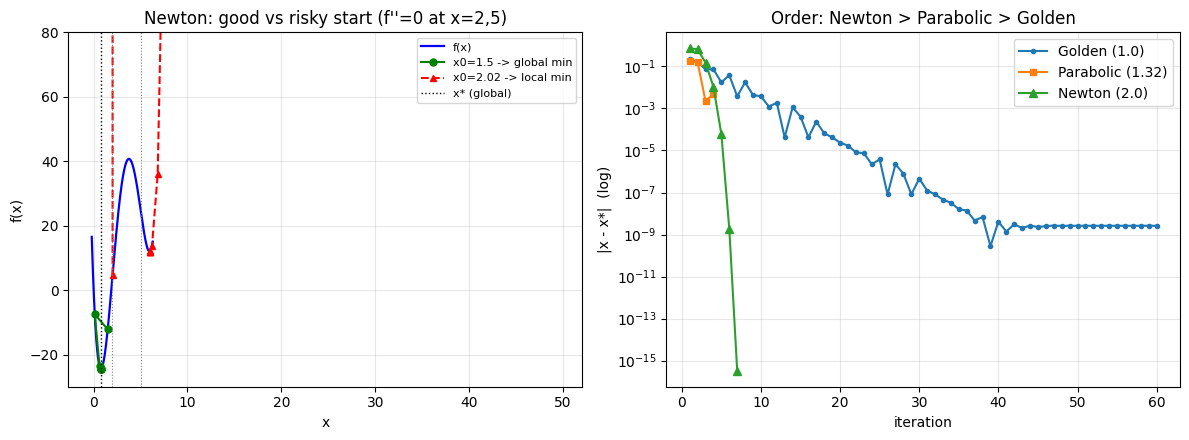

In [7]:
# 시각화: (좌) Newton 의 좋은/나쁜 출발,  (우) 세 방법 오차 semilog
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

xx = np.linspace(-0.2, 6.3, 600)
ax[0].plot(xx, f(xx), 'b-', lw=1.6, label='f(x)')
ax[0].plot(dfn['x'], [f(v) for v in dfn['x']], 'go-', ms=5, label='x0=1.5 -> global min')
ffx = df_fail['x'][np.isfinite(df_fail['x'])]
ax[0].plot(ffx, [f(v) for v in ffx], 'r^--', ms=5, label='x0=2.02 -> local min')
ax[0].axvline(XSTAR, color='k', ls=':', lw=1, label='x* (global)')
ax[0].axvline(2, color='gray', ls=':', lw=.8); ax[0].axvline(5, color='gray', ls=':', lw=.8)
ax[0].set_ylim(-30, 80); ax[0].set_xlabel('x'); ax[0].set_ylabel('f(x)')
ax[0].set_title("Newton: good vs risky start (f''=0 at x=2,5)"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

def golden_errs(a, b, tol=1e-12):
    x1=b-tau*(b-a); x2=a+tau*(b-a); f1,f2=f(x1),f(x2); e=[]
    for _ in range(120):
        e.append(abs(0.5*(a+b)-XSTAR))
        if (b-a) < tol: break
        if f1<f2: b,x2,f2=x2,x1,f1; x1=b-tau*(b-a); f1=f(x1)
        else: a,x1,f1=x1,x2,f2; x2=a+tau*(b-a); f2=f(x2)
    return e
def parab_errs():
    x0,x1,x2=0.0,1.0,2.0; f0,f1,f2=f(x0),f(x1),f(x2); e=[]
    for _ in range(25):
        xv=vertex(x0,x1,x2,f0,f1,f2)
        if xv is None: break
        er=abs(xv-XSTAR); e.append(er)
        if len(e)>=2 and e[-1]>=e[-2]: break
        x0,x1,x2=x1,x2,xv; f0,f1,f2=f1,f2,f(xv)
    return e
eg=golden_errs(0,2); ep=parab_errs(); en2=dfn['err'].values
ax[1].semilogy(range(1,len(eg)+1), np.maximum(eg,1e-17),'o-',ms=3,label='Golden (1.0)')
ax[1].semilogy(range(1,len(ep)+1), np.maximum(ep,1e-17),'s-',ms=5,label='Parabolic (1.32)')
ax[1].semilogy(range(1,len(en2)+1), np.maximum(en2,1e-17),'^-',ms=6,label='Newton (2.0)')
ax[1].set_xlabel('iteration'); ax[1].set_ylabel('|x - x*|  (log)')
ax[1].set_title('Order: Newton > Parabolic > Golden'); ax[1].legend(); ax[1].grid(alpha=.3,which='both')

plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **Newton 은 2차 수렴 + 기계정밀도.** 좋은 출발점에서 경험적 수렴차수가 $p\to2.0$ 으로 가고, 오차 semilog 가 *아래로 꺾이며* 6-7 회 만에 $\sim10^{-16}$ 에 도달한다. $f'(x)=0$ 의 근은 *평탄하지 않아*($f''\ne0$) Problem 2 의 $\sqrt{\varepsilon}$ 바닥이 없다 - 정확 자릿수가 매 반복 약 두 배.
2. **공짜가 아니다.** 반복당 $f',f''$ 두 도함수 평가가 필요하다. 해석적 도함수가 없으면 수치미분 비용/오차가 붙는다 - *평가당 효율*로는 도함수 없는 parabolic 이 나을 때도 있다.
3. **전역성이 없다.** $x_0=2.02$($f''\approx0$)에서 출발하면 첫 도약이 폭발해 오른쪽 분지로 날아가 *국소* 최소 $x\approx5.957$ 로 수렴 - 전역 최소 $0.781$ 을 놓친다. Newton 은 최소/최대도, 전역/국소도 구분 못 하고 bracketing 안전망도 없다. 그래서 실전 최소화기는 **Newton(빠름) + golden(안전)** 을 묶는다.
4. **root finding 과의 대응.** golden(이분법; 선형/안전), parabolic(secant; 초선형/도함수 불요), Newton-min(Newton-root; 2차/도함수 필요) - Day 11-13 의 구조가 *한 번 미분된* 형태로 반복된다.

> **결론**: Newton 최소화는 $f'=0$ 에 Newton 을 적용한 *2차 수렴, 기계정밀도*로 가장 빠르고 정확하지만 도함수 2개가 필요하고 전역 최소를 보장하지 않는다 - 속도(Newton)/도함수 자유(parabolic)/안전성(golden)의 삼각 trade-off 가 §13.1 의 핵심이다.

**다음 단원으로 연결**: 한 변수 최소화의 세 축(안전/초선형/2차)을 잡았으니, 다음은 **다변수 최소화**(경사하강/켤레기울기/Newton/BFGS)로 확장한다 - 도함수는 *기울기 벡터*, 2계도함수는 *헤시안 행렬*이 되어 오늘의 trade-off 가 고차원에서 재현된다.